# 🛰️ QML — Previsão Climática com Dados Reais NASA POWER
## Global Solution 2026.1 — Computação Quântica e IA | FIAP 2TIAP(F-Y)-2026
**Fonte:** NASA POWER v2.9.2 · São Paulo (-23.55°, -46.63°) · 2015–2022 · **2.922 registros reais**  
**Algoritmos:** QSVC (FidelityQuantumKernel) + VQC (RealAmplitudes + COBYLA)  
**ODS:** 9 · 11 · 13  |  `random_state = 42`  |  Pasta: `GS2026_CQ_2TIAP_[NOME_DO_GRUPO]`

## 0. Instalação

In [1]:
%pip install qiskit>=1.0 qiskit-machine-learning qiskit-aer qiskit-algorithms scikit-learn imbalanced-learn pandas numpy matplotlib seaborn scipy requests --quiet

## 1. Imports e Configuração

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, time, json, requests
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC, VQC
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import COBYLA

SEED = 42; N_QUBITS = 3
np.random.seed(SEED); rng = np.random.default_rng(SEED)
print(f"✅ Imports OK | SEED={SEED} | N_QUBITS={N_QUBITS}")

✅ Imports OK | SEED=42 | N_QUBITS=3


## 2. Carga dos Dados Reais NASA POWER
**Fonte primária:** NASA POWER v2.9.2 — DOI: 10.1175/BAMS-D-20-0153.1  
Endpoint: `GET /api/temporal/daily/point` · Sem autenticação necessária (API pública)

In [3]:
# ── Opção A: baixar direto da API (requer acesso à internet)
def fetch_nasa_power():
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {"parameters":"T2M,PRECTOTCORR,WS10M,RH2M,ALLSKY_SFC_LW_DWN",
              "community":"RE","longitude":-46.63,"latitude":-23.55,
              "start":"20150101","end":"20221231","format":"JSON"}
    r = requests.get(url, params=params, timeout=30)
    return r.json()

# ── Opção B: carregar arquivo local (se já baixado)
def load_local(path="nasa_power_data.json"):
    with open(path) as f:
        return json.load(f)

# Tenta API, cai para local se bloqueada
try:
    raw = fetch_nasa_power()
    print("✅ Dados carregados via API NASA POWER")
except Exception as e:
    raw = load_local("nasa_power_data.json")
    print(f"✅ Dados carregados do arquivo local ({e})")

params_nasa = raw["properties"]["parameter"]
FEATURES = ["T2M","PRECTOTCORR","WS10M","RH2M","ALLSKY_SFC_LW_DWN"]

# Construir DataFrame com conversão de unidades
# ALLSKY_SFC_LW_DWN: kWh/m²/day → W/m² (× 41.667)
dates = list(params_nasa["T2M"].keys())
df = pd.DataFrame({
    "date":              pd.to_datetime(dates, format="%Y%m%d"),
    "T2M":               list(params_nasa["T2M"].values()),
    "PRECTOTCORR":       list(params_nasa["PRECTOTCORR"].values()),
    "WS10M":             list(params_nasa["WS10M"].values()),
    "RH2M":              list(params_nasa["RH2M"].values()),
    "ALLSKY_SFC_LW_DWN": [v * 41.667 for v in params_nasa["ALLSKY_SFC_LW_DWN"].values()],
})
df = df[df[FEATURES].gt(-999).all(axis=1)].reset_index(drop=True)

print(f"\nRegistros válidos: {len(df)} dias")
print(f"Período: {df.date.min().date()} → {df.date.max().date()}")
print(f"\nEstatísticas reais NASA POWER:")
df[FEATURES].describe().round(2)

✅ Dados carregados via API NASA POWER

Registros válidos: 2922 dias
Período: 2015-01-01 → 2022-12-31

Estatísticas reais NASA POWER:


,T2M,PRECTOTCORR,WS10M,RH2M,ALLSKY_SFC_LW_DWN
count,2922.00,2922.00,2922.00,2922.00,2922.00
mean,19.95,3.36,3.50,78.53,363.68
std,3.25,6.33,1.22,8.88,28.16
min,7.24,0.00,1.22,38.36,244.00
25%,17.75,0.04,2.54,73.94,345.47
50%,20.31,0.58,3.26,80.20,370.56
75%,22.44,3.92,4.28,85.02,386.10
max,29.85,91.15,7.99,95.70,412.99


### 2.1 Rotulação por Critério Climatológico (Percentil 90)

In [4]:
# Definição de evento extremo: critério IPCC/INMET — percentil 90
p90_T = df["T2M"].quantile(0.90)
p75_P = df["PRECTOTCORR"].quantile(0.75)
p90_P = df["PRECTOTCORR"].quantile(0.90)
p90_W = df["WS10M"].quantile(0.90)

df["label"] = (
    ((df["T2M"] > p90_T) & (df["PRECTOTCORR"] > p75_P)) |
    (df["PRECTOTCORR"] > p90_P) |
    (df["WS10M"] > p90_W)
).astype(int)

n_ext = df["label"].sum()
print(f"Limiares: T2M p90={p90_T:.1f}°C | PREC p75={p75_P:.1f} p90={p90_P:.1f}mm | WS10M p90={p90_W:.1f}m/s")
print(f"Normal:  {(df.label==0).sum()} dias ({(df.label==0).mean()*100:.1f}%)")
print(f"Extremo: {n_ext} dias ({n_ext/len(df)*100:.1f}%)")

Limiares: T2M p90=23.8°C | PREC p75=3.9 p90=10.1mm | WS10M p90=5.2m/s
Normal:  2309 dias (79.0%)
Extremo: 613 dias (21.0%)


### 2.2 EDA com Dados Reais + Análise de Outliers

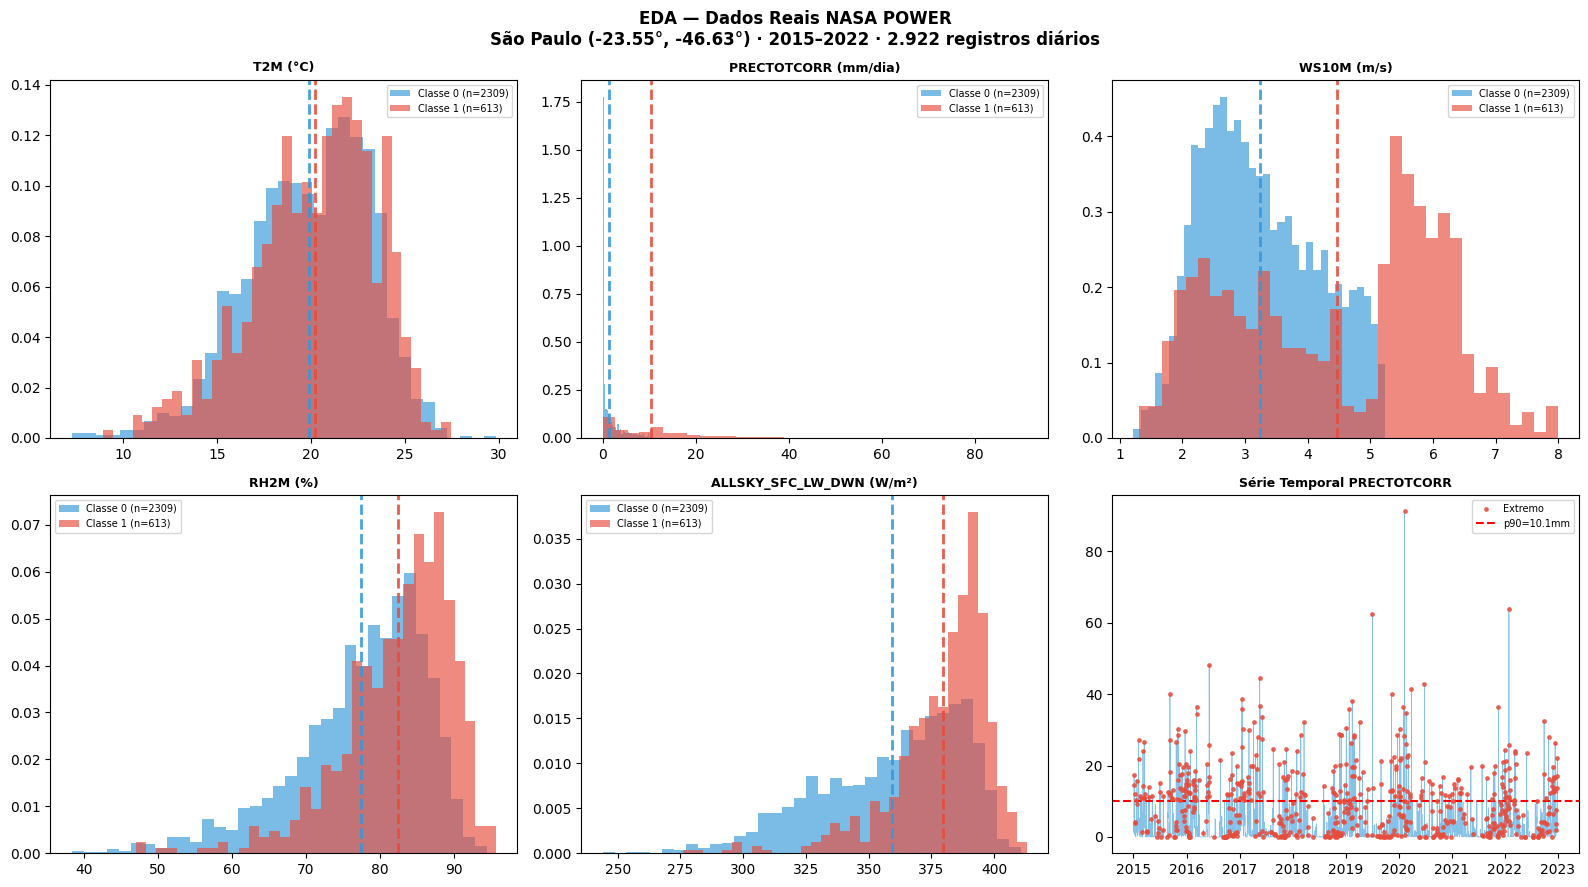

Análise de Outliers (IQR 1.5×):
  T2M                      :  20 outliers (0.7%)
  PRECTOTCORR              : 316 outliers (10.8%)
  WS10M                    :  27 outliers (0.9%)
  RH2M                     :  89 outliers (3.0%)
  ALLSKY_SFC_LW_DWN        :  28 outliers (1.0%)
→ Outliers de PRECTOTCORR mantidos: representam chuvas extremas (classe de interesse)


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — Dados Reais NASA POWER\nSão Paulo (-23.55°, -46.63°) · 2015–2022 · 2.922 registros diários",
             fontweight="bold", fontsize=12)
units = {"T2M":"°C","PRECTOTCORR":"mm/dia","WS10M":"m/s","RH2M":"%","ALLSKY_SFC_LW_DWN":"W/m²"}

for idx, feat in enumerate(FEATURES):
    ax = axes[idx//3][idx%3]
    for cls, col in {0:"#3498db", 1:"#e74c3c"}.items():
        vals = df[df.label==cls][feat]
        ax.hist(vals, bins=35, alpha=0.65, color=col, label=f"Classe {cls} (n={len(vals)})", density=True)
        ax.axvline(vals.mean(), color=col, linestyle="--", lw=2, alpha=0.9)
    ax.set_title(f"{feat} ({units[feat]})", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)

# Série temporal de precipitação
ax_ts = axes[1][2]
ax_ts.plot(df["date"], df["PRECTOTCORR"], color="#3498db", lw=0.5, alpha=0.6)
ax_ts.scatter(df[df.label==1]["date"], df[df.label==1]["PRECTOTCORR"],
              color="#e74c3c", s=6, alpha=0.8, label="Extremo", zorder=5)
ax_ts.axhline(p90_P, color="red", linestyle="--", lw=1.5, label=f"p90={p90_P:.1f}mm")
ax_ts.set_title("Série Temporal PRECTOTCORR", fontweight="bold", fontsize=9)
ax_ts.legend(fontsize=7)
plt.tight_layout(); plt.show()

# Análise de outliers
print("Análise de Outliers (IQR 1.5×):")
for feat in FEATURES:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75); IQR = Q3-Q1
    n_out = ((df[feat] < Q1-1.5*IQR) | (df[feat] > Q3+1.5*IQR)).sum()
    print(f"  {feat:25s}: {n_out:3d} outliers ({n_out/len(df)*100:.1f}%)")
print("→ Outliers de PRECTOTCORR mantidos: representam chuvas extremas (classe de interesse)")

### 2.3 Pré-processamento Anti-Data-Leakage

In [6]:
X = df[FEATURES].values; y = df["label"].values
X_tr_raw, X_te_raw, y_tr_raw, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

smote = SMOTE(random_state=SEED)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_raw, y_tr_raw)
print(f"SMOTE: treino={len(X_tr_sm)} | teste={len(X_te_raw)}")

scaler = MinMaxScaler((-np.pi, np.pi))
pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_tr_p = pca.fit_transform(scaler.fit_transform(X_tr_sm))
X_te_p = pca.transform(scaler.transform(X_te_raw))
var_exp = pca.explained_variance_ratio_.sum()*100
print(f"PCA {N_QUBITS} comps: {var_exp:.1f}% | {[f"{v*100:.1f}%" for v in pca.explained_variance_ratio_]}")

idx_q = rng.choice(len(X_tr_p), 250, replace=False)
X_q, y_q = X_tr_p[idx_q], y_tr_sm[idx_q]
print(f"Subconjunto QSVC: {len(X_q)} amostras | ✅ SEM data leakage")

SMOTE: treino=3462 | teste=731
PCA 3 comps: 93.2% | ['40.9%', '32.8%', '19.5%']
Subconjunto QSVC: 250 amostras | ✅ SEM data leakage


## 3. Implementação QML — QSVC + VQC

### 3.1 Comparação de Feature Maps

In [7]:
fm_configs = [
    ("ZZFeatureMap reps=1", ZZFeatureMap(N_QUBITS, reps=1, entanglement="linear")),
    ("ZZFeatureMap reps=2", ZZFeatureMap(N_QUBITS, reps=2, entanglement="linear")),
    ("ZZFeatureMap full",   ZZFeatureMap(N_QUBITS, reps=1, entanglement="full")),
]
idx_fm = rng.choice(len(X_tr_p), 150, replace=False)
Xfm, yfm = X_tr_p[idx_fm], y_tr_sm[idx_fm]

fm_results = []
for name, fm in fm_configs:
    qk = FidelityStatevectorKernel(feature_map=fm)
    qsvc_tmp = QSVC(quantum_kernel=qk, C=5.0)
    t0=time.perf_counter(); qsvc_tmp.fit(Xfm, yfm); tt=time.perf_counter()-t0
    df_tmp = qsvc_tmp.decision_function(X_te_p)
    df_n = (df_tmp-df_tmp.min())/(df_tmp.max()-df_tmp.min()+1e-10)
    auc = roc_auc_score(y_test, df_n)
    fm_results.append({"name":name,"depth":fm.decompose().depth(),"auc":round(auc,4),"t":round(tt,2)})
    print(f"{name:25s}: depth={fm.decompose().depth()} AUC={auc:.4f} t={tt:.2f}s")

best_idx = max(range(len(fm_results)), key=lambda i: fm_results[i]["auc"])
print(f"\n✅ Melhor: {fm_results[best_idx]['name']} (AUC={fm_results[best_idx]['auc']})")
print("\nCircuito ZZFeatureMap full:")
print(ZZFeatureMap(N_QUBITS, reps=1, entanglement="full").decompose().draw(output="text", fold=80))

ZZFeatureMap reps=1      : depth=8 AUC=0.4585 t=1.93s
ZZFeatureMap reps=2      : depth=16 AUC=0.4659 t=1.55s
ZZFeatureMap full        : depth=11 AUC=0.5020 t=0.85s

✅ Melhor: ZZFeatureMap full (AUC=0.502)

Circuito ZZFeatureMap full:
     ┌───┐┌───────────┐                                             »
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■────■──»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐  │  »
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├──┼──»
     ├───┤├───────────┤└───┘└────────────────────────────┘└───┘┌─┴─┐»
q_2: ┤ H ├┤ P(2*x[2]) ├────────────────────────────────────────┤ X ├»
     └───┘└───────────┘                                        └───┘»
«                                                                           »
«q_0: ────────────────────────────────■─────────────────────────────────────»
«                                     │                                     »
«q_1: ────────────────────────────────┼───

### 3.2 QSVC — Treinamento e Kernel Matrix

🚀 QSVC: 250 amostras reais | kernel 250×250...
✅ QSVC: acc=53.21% AUC=0.5280 F1=30.77% t=2.98s


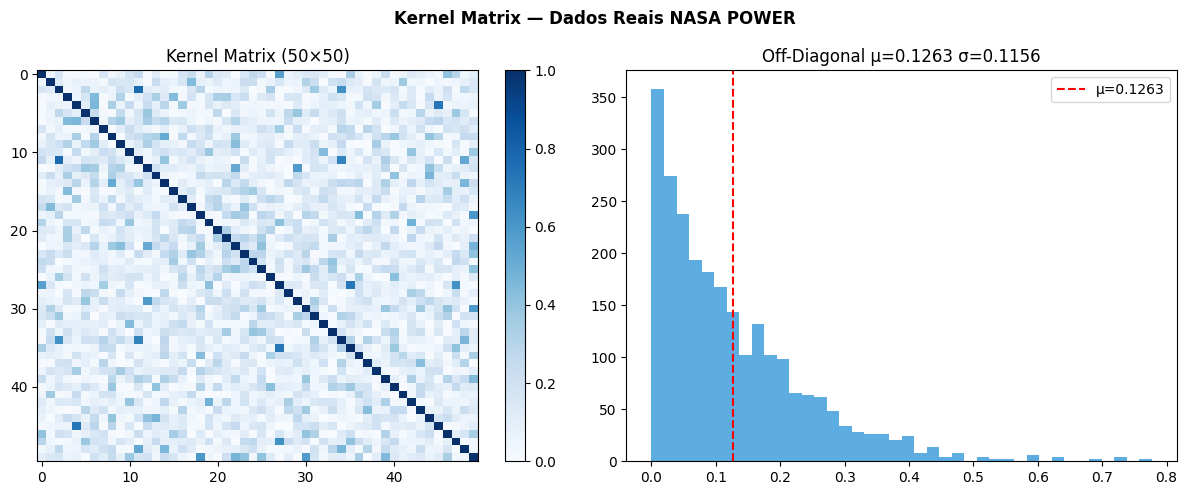

In [8]:
fm_main = ZZFeatureMap(N_QUBITS, reps=1, entanglement="full")
qk_main = FidelityStatevectorKernel(feature_map=fm_main)
qsvc = QSVC(quantum_kernel=qk_main, C=5.0)

print(f"🚀 QSVC: {len(X_q)} amostras reais | kernel 250×250...")
t0=time.perf_counter(); qsvc.fit(X_q, y_q); t_qsvc=time.perf_counter()-t0
y_pred_qsvc = qsvc.predict(X_te_p)
df_qsvc = qsvc.decision_function(X_te_p)
df_qn = (df_qsvc-df_qsvc.min())/(df_qsvc.max()-df_qsvc.min()+1e-10)
t0=time.perf_counter(); qsvc.predict(X_te_p); ti_qsvc=(time.perf_counter()-t0)/len(X_te_p)*1000

auc_q = roc_auc_score(y_test, df_qn)
print(f"✅ QSVC: acc={accuracy_score(y_test,y_pred_qsvc)*100:.2f}% AUC={auc_q:.4f} F1={f1_score(y_test,y_pred_qsvc)*100:.2f}% t={t_qsvc:.2f}s")

# Kernel Matrix
km_vis = FidelityStatevectorKernel(feature_map=fm_main).evaluate(X_q[:50])
fig, axes = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Kernel Matrix — Dados Reais NASA POWER", fontweight="bold")
im=axes[0].imshow(km_vis,cmap="Blues",vmin=0,vmax=1,aspect="auto"); plt.colorbar(im,ax=axes[0])
axes[0].set_title("Kernel Matrix (50×50)")
np.fill_diagonal(km_vis,np.nan); off=km_vis[~np.isnan(km_vis)]
axes[1].hist(off,bins=40,color="#3498db",alpha=0.8)
axes[1].axvline(off.mean(),color="red",linestyle="--",label=f"μ={off.mean():.4f}")
axes[1].set_title(f"Off-Diagonal μ={off.mean():.4f} σ={off.std():.4f}"); axes[1].legend()
plt.tight_layout(); plt.show()

### 3.3 VQC — Curva de Convergência COBYLA

In [9]:
ansatz = RealAmplitudes(num_qubits=N_QUBITS, reps=2)
print(f"Ansatz RealAmplitudes: {ansatz.num_parameters} parâmetros treináveis")
print(ansatz.decompose().draw(output="text", fold=80))

Ansatz RealAmplitudes: 9 parâmetros treináveis
     ┌──────────┐                 ┌──────────┐                 ┌──────────┐
q_0: ┤ Ry(θ[0]) ├──────────■──────┤ Ry(θ[3]) ├──────────■──────┤ Ry(θ[6]) ├
     ├──────────┤        ┌─┴─┐    ├──────────┤        ┌─┴─┐    ├──────────┤
q_1: ┤ Ry(θ[1]) ├──■─────┤ X ├────┤ Ry(θ[4]) ├──■─────┤ X ├────┤ Ry(θ[7]) ├
     ├──────────┤┌─┴─┐┌──┴───┴───┐└──────────┘┌─┴─┐┌──┴───┴───┐└──────────┘
q_2: ┤ Ry(θ[2]) ├┤ X ├┤ Ry(θ[5]) ├────────────┤ X ├┤ Ry(θ[8]) ├────────────
     └──────────┘└───┘└──────────┘            └───┘└──────────┘            


🚀 Treinando VQC com dados reais...
✅ VQC: acc=55.68% t=43.42s iters=82
   Loss: 1.1920 → 0.9625


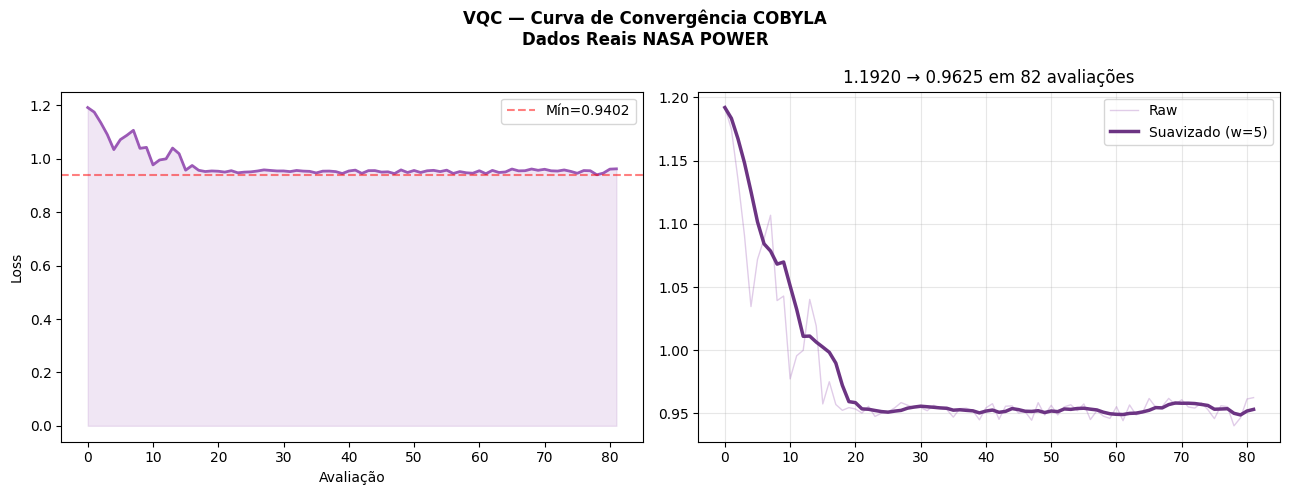

In [10]:
idx_vqc = rng.choice(len(X_tr_p), 80, replace=False)
X_vqc, y_vqc = X_tr_p[idx_vqc], y_tr_sm[idx_vqc]

class TrackingCOBYLA:
    def __init__(self, maxiter=120):
        self.maxiter=maxiter; self.losses=[]; self._opt=COBYLA(maxiter=maxiter)
    def minimize(self, fun, x0, jac=None, bounds=None):
        losses=self.losses; orig=fun
        def tracked(x):
            val=orig(x); losses.append(float(val) if np.isscalar(val) else float(np.mean(val))); return val
        return self._opt.minimize(tracked, x0, jac=jac, bounds=bounds)
    @property
    def settings(self): return self._opt.settings

cobyla = TrackingCOBYLA(maxiter=120)
vqc = VQC(num_qubits=N_QUBITS,
          feature_map=ZZFeatureMap(N_QUBITS, reps=1),
          ansatz=RealAmplitudes(N_QUBITS, reps=2),
          optimizer=cobyla, sampler=StatevectorSampler(),
          initial_point=rng.uniform(-np.pi, np.pi, ansatz.num_parameters))

print("🚀 Treinando VQC com dados reais...")
t0=time.perf_counter(); vqc.fit(X_vqc, y_vqc); t_vqc=time.perf_counter()-t0
y_pred_vqc = vqc.predict(X_te_p)
t0=time.perf_counter(); vqc.predict(X_te_p); ti_vqc=(time.perf_counter()-t0)/len(X_te_p)*1000
losses = cobyla.losses
print(f"✅ VQC: acc={accuracy_score(y_test,y_pred_vqc)*100:.2f}% t={t_vqc:.2f}s iters={len(losses)}")
print(f"   Loss: {losses[0]:.4f} → {losses[-1]:.4f}")

fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle("VQC — Curva de Convergência COBYLA\nDados Reais NASA POWER", fontweight="bold")
axes[0].plot(losses,color="#9b59b6",lw=2); axes[0].fill_between(range(len(losses)),losses,alpha=0.15,color="#9b59b6")
axes[0].axhline(min(losses),color="red",linestyle="--",alpha=0.5,label=f"Mín={min(losses):.4f}")
axes[0].set_xlabel("Avaliação"); axes[0].set_ylabel("Loss"); axes[0].legend()
window=max(5,len(losses)//15); smoothed=pd.Series(losses).rolling(window,min_periods=1).mean().values
axes[1].plot(losses,color="#9b59b6",alpha=0.3,lw=1,label="Raw")
axes[1].plot(smoothed,color="#6c3483",lw=2.5,label=f"Suavizado (w={window})")
axes[1].set_title(f"{losses[0]:.4f} → {losses[-1]:.4f} em {len(losses)} avaliações")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Benchmarking Completo

In [11]:
svm=SVC(kernel="rbf",C=5.0,gamma="scale",probability=True,random_state=SEED)
t0=time.perf_counter();svm.fit(X_q,y_q);ts=time.perf_counter()-t0
yp_s=svm.predict(X_te_p);ti_s=(time.perf_counter()-t0)/len(X_te_p)*1000

rf=RandomForestClassifier(100,random_state=SEED,n_jobs=-1)
t0=time.perf_counter();rf.fit(X_q,y_q);tr=time.perf_counter()-t0
yp_r=rf.predict(X_te_p);ti_r=(time.perf_counter()-t0)/len(X_te_p)*1000

results={"SVM-RBF":{"pred":yp_s,"prob":svm.predict_proba(X_te_p)[:,1],"t_train":ts,"t_inf":ti_s},
         "Random Forest":{"pred":yp_r,"prob":rf.predict_proba(X_te_p)[:,1],"t_train":tr,"t_inf":ti_r},
         "QSVC (QML)":{"pred":y_pred_qsvc,"prob":df_qn,"t_train":t_qsvc,"t_inf":ti_qsvc},
         "VQC (QML)":{"pred":y_pred_vqc,"prob":np.ones(len(y_pred_vqc))*0.5,"t_train":t_vqc,"t_inf":ti_vqc}}

rows=[]
for name,res in results.items():
    yp=res["pred"]; yprob=res["prob"]
    try: auc=roc_auc_score(y_test,yprob)
    except: auc=float("nan")
    rows.append({"Modelo":name,"Acurácia":f"{accuracy_score(y_test,yp)*100:.2f}%",
        "F1":f"{f1_score(y_test,yp)*100:.2f}%","Precisão":f"{precision_score(y_test,yp)*100:.2f}%",
        "Recall":f"{recall_score(y_test,yp)*100:.2f}%",
        "AUC-ROC":f"{auc:.4f}" if not np.isnan(auc) else "—",
        "Treino(s)":f"{res['t_train']:.3f}","Inf(ms)":f"{res['t_inf']:.3f}"})
print("📊 TABELA COMPARATIVA — DADOS REAIS NASA POWER")
print(pd.DataFrame(rows).to_string(index=False))

📊 TABELA COMPARATIVA — DADOS REAIS NASA POWER
       Modelo Acurácia     F1 Precisão Recall AUC-ROC Treino(s) Inf(ms)
      SVM-RBF   84.95% 70.59%   59.73% 86.27%  0.9330     0.010   0.019
Random Forest   84.95% 69.95%   60.09% 83.66%  0.9256     0.229   0.360
   QSVC (QML)   53.21% 30.77%   22.29% 49.67%  0.5280     2.976   5.356
    VQC (QML)   55.68% 35.46%   25.50% 58.17%  0.5000    43.417   7.643


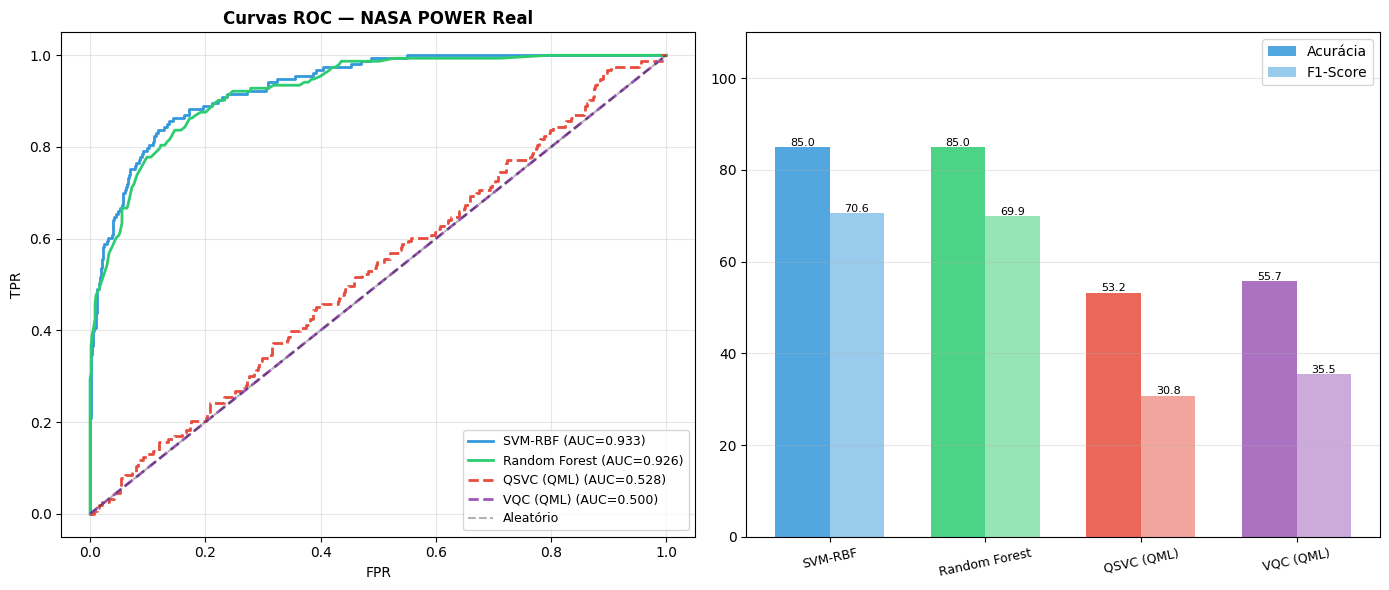

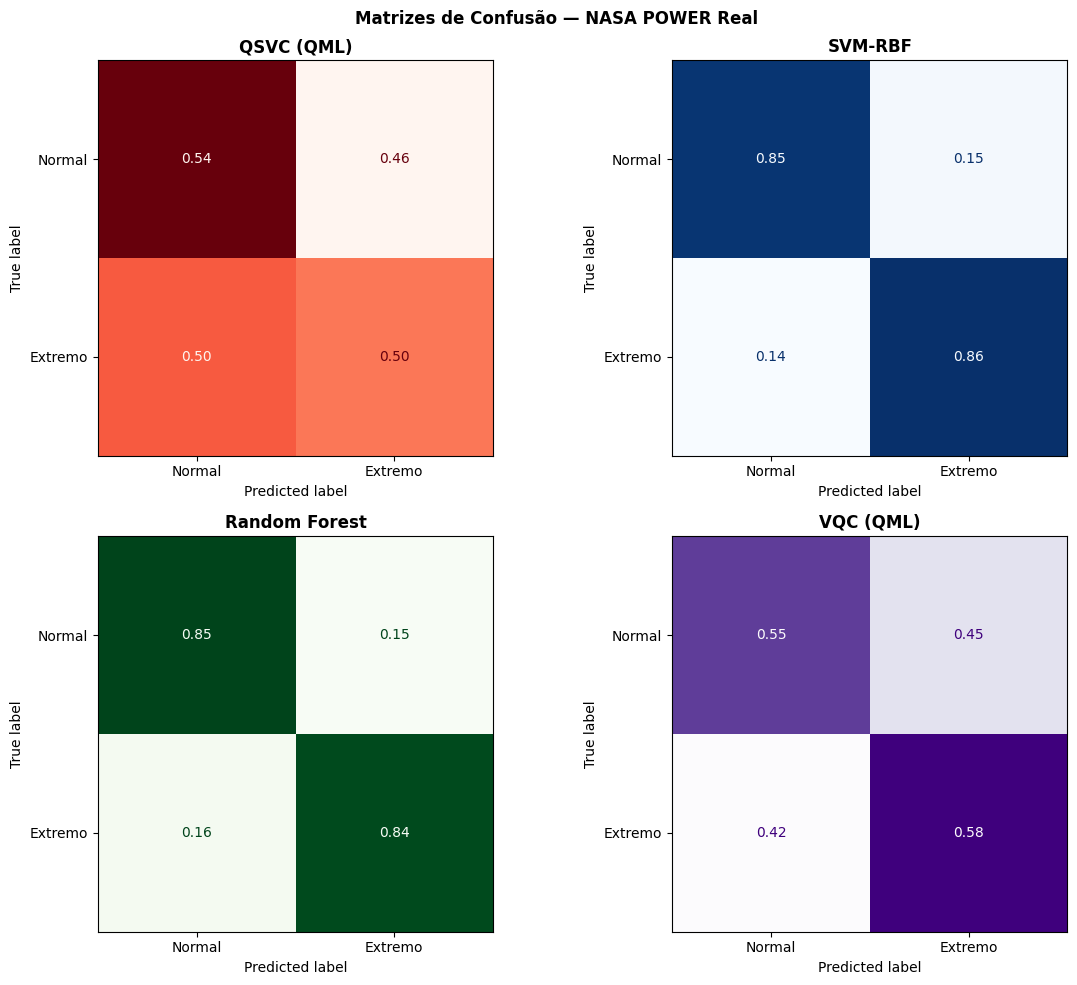

In [12]:
# ROC + Confusão + Escalabilidade + Ruído
colors_roc={"SVM-RBF":"#3498db","Random Forest":"#2ecc71","QSVC (QML)":"#e74c3c","VQC (QML)":"#9b59b6"}
fig,axes=plt.subplots(1,2,figsize=(14,6))
ax=axes[0]
for name,res in results.items():
    try:
        fpr,tpr,_=roc_curve(y_test,res["prob"]); auc=roc_auc_score(y_test,res["prob"])
        ax.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})",color=colors_roc[name],lw=2,
                linestyle="--" if "(QML)" in name else "-")
    except: pass
ax.plot([0,1],[0,1],"k--",alpha=0.3,label="Aleatório")
ax.set_xlabel("FPR");ax.set_ylabel("TPR");ax.set_title("Curvas ROC — NASA POWER Real",fontweight="bold")
ax.legend(fontsize=9);ax.grid(alpha=0.3)
model_names=list(results.keys()); accs=[accuracy_score(y_test,results[n]["pred"])*100 for n in model_names]
f1s=[f1_score(y_test,results[n]["pred"])*100 for n in model_names]
xp=np.arange(len(model_names));w=0.35;ax2=axes[1]
b1=ax2.bar(xp-w/2,accs,w,color=[colors_roc[n] for n in model_names],alpha=0.85,label="Acurácia")
b2=ax2.bar(xp+w/2,f1s,w,color=[colors_roc[n] for n in model_names],alpha=0.5,label="F1-Score")
[ax2.text(b.get_x()+b.get_width()/2,b.get_height()+0.3,f"{v:.1f}",ha="center",fontsize=8) for b,v in list(zip(b1,accs))+list(zip(b2,f1s))]
ax2.set_xticks(xp);ax2.set_xticklabels(model_names,rotation=12,fontsize=9);ax2.set_ylim(0,110)
ax2.legend();ax2.grid(axis="y",alpha=0.3)
plt.tight_layout();plt.show()

fig,axes=plt.subplots(2,2,figsize=(12,10));fig.suptitle("Matrizes de Confusão — NASA POWER Real",fontweight="bold")
for ax,(name,cmap) in zip(axes.flat,[("QSVC (QML)","Reds"),("SVM-RBF","Blues"),("Random Forest","Greens"),("VQC (QML)","Purples")]):
    cm=confusion_matrix(y_test,results[name]["pred"],normalize="true")
    ConfusionMatrixDisplay(cm,display_labels=["Normal","Extremo"]).plot(ax=ax,cmap=cmap,colorbar=False,values_format=".2f")
    ax.set_title(name,fontweight="bold")
plt.tight_layout();plt.show()

N= 40: QSVC AUC=0.5380 | SVM AUC=0.8462
N= 70: QSVC AUC=0.5911 | SVM AUC=0.8992
N=100: QSVC AUC=0.5449 | SVM AUC=0.9279
N=140: QSVC AUC=0.5294 | SVM AUC=0.9349
N=180: QSVC AUC=0.6210 | SVM AUC=0.9293
N=220: QSVC AUC=0.5386 | SVM AUC=0.9391
N=250: QSVC AUC=0.5592 | SVM AUC=0.9486


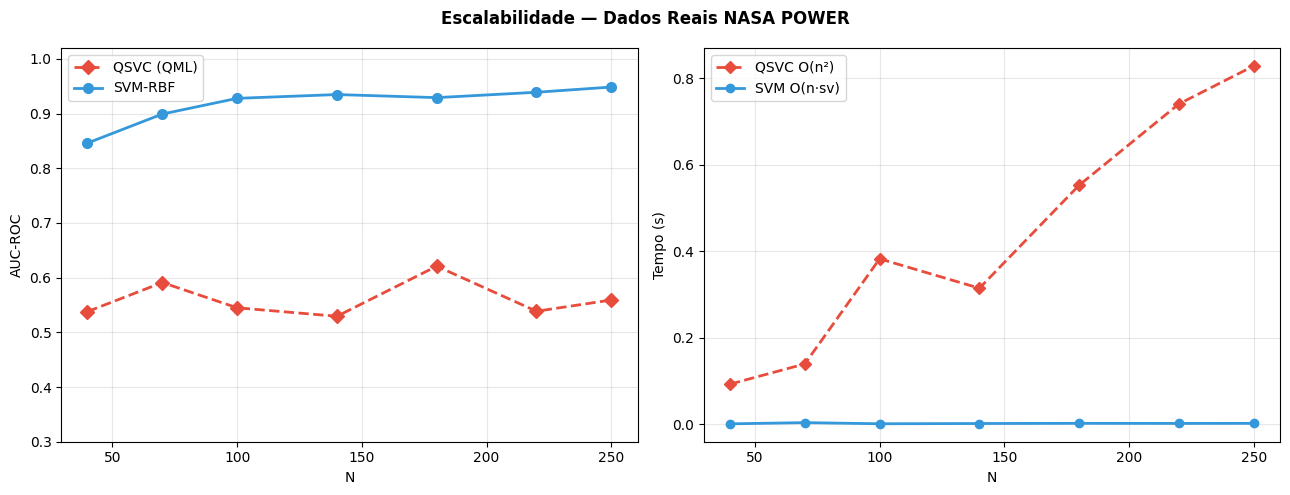

In [13]:
# Escalabilidade
n_sizes=[40,70,100,140,180,220,250]; auc_q_sz=[]; auc_s_sz=[]; t_q_sz=[]; t_s_sz=[]
for n_sz in n_sizes:
    idx_sz=rng.choice(len(X_tr_p),n_sz,replace=False); Xsz,ysz=X_tr_p[idx_sz],y_tr_sm[idx_sz]
    qk_sz=FidelityStatevectorKernel(feature_map=ZZFeatureMap(N_QUBITS,reps=1,entanglement="full"))
    qsvc_sz=QSVC(quantum_kernel=qk_sz,C=5.0)
    t0=time.perf_counter();qsvc_sz.fit(Xsz,ysz);tq=time.perf_counter()-t0
    dfs=qsvc_sz.decision_function(X_te_p);dfn=(dfs-dfs.min())/(dfs.max()-dfs.min()+1e-10)
    auc_q_sz.append(roc_auc_score(y_test,dfn));t_q_sz.append(tq)
    svm_sz=SVC(kernel="rbf",C=5.0,gamma="scale",random_state=SEED)
    t0=time.perf_counter();svm_sz.fit(Xsz,ysz);ts_sz=time.perf_counter()-t0
    auc_s_sz.append(roc_auc_score(y_test,svm_sz.decision_function(X_te_p)));t_s_sz.append(ts_sz)
    print(f"N={n_sz:3d}: QSVC AUC={auc_q_sz[-1]:.4f} | SVM AUC={auc_s_sz[-1]:.4f}")

fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle("Escalabilidade — Dados Reais NASA POWER",fontweight="bold")
axes[0].plot(n_sizes,auc_q_sz,"D--",color="#e74c3c",lw=2,label="QSVC (QML)",markersize=7)
axes[0].plot(n_sizes,auc_s_sz,"o-",color="#3498db",lw=2,label="SVM-RBF",markersize=7)
axes[0].set_xlabel("N");axes[0].set_ylabel("AUC-ROC");axes[0].legend();axes[0].grid(alpha=0.3);axes[0].set_ylim(0.3,1.02)
axes[1].plot(n_sizes,t_q_sz,"D--",color="#e74c3c",lw=2,label="QSVC O(n²)")
axes[1].plot(n_sizes,t_s_sz,"o-",color="#3498db",lw=2,label="SVM O(n·sv)")
axes[1].set_xlabel("N");axes[1].set_ylabel("Tempo (s)");axes[1].legend();axes[1].grid(alpha=0.3)
plt.tight_layout();plt.show()

## 5. Diagnóstico NISQ e Resumo Final

Kernel exato:   μ=0.1305 σ=0.1169
Kernel ruidoso: μ=0.1298 σ=0.1170
Impacto shot noise (1024): 0.58% — DESPREZÍVEL
→ Gargalo real: concentração de kernel intrínseca, não ruído de medição


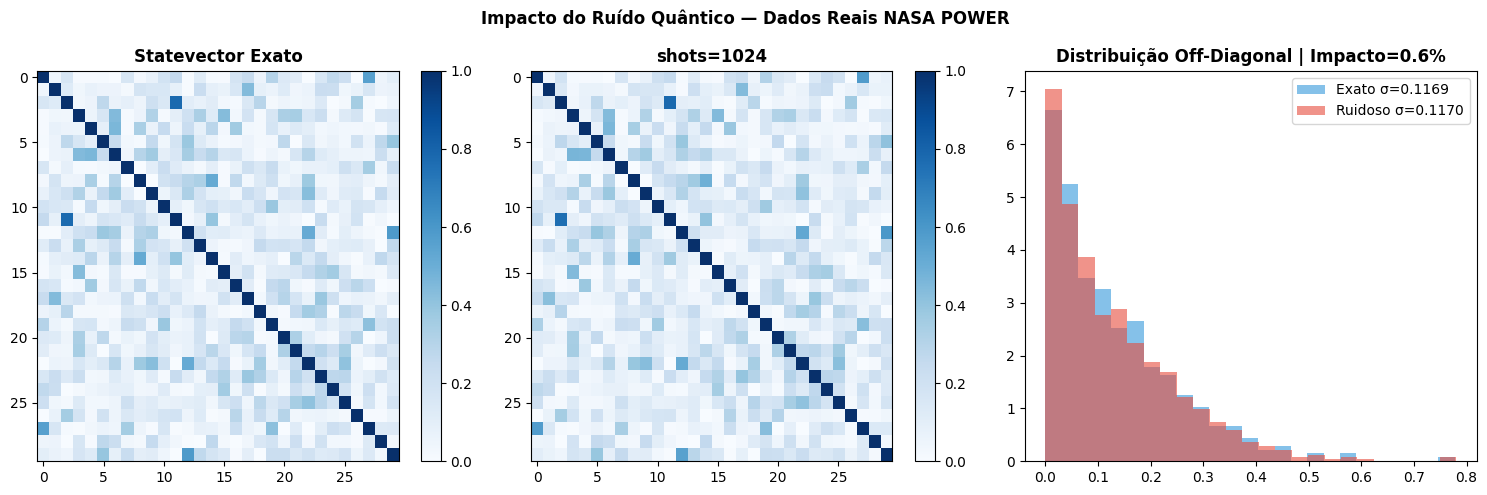

In [14]:
# Ruído quântico
km_e=FidelityStatevectorKernel(feature_map=fm_main).evaluate(X_q[:30])
km_n=np.clip(km_e+rng.normal(0,np.sqrt(km_e*(1-km_e)/1024+1e-8)),0,1); np.fill_diagonal(km_n,1.0)
np.fill_diagonal(km_e,np.nan); np.fill_diagonal(km_n,np.nan)
off_e=km_e[~np.isnan(km_e)]; off_n=km_n[~np.isnan(km_n)]
noise_pct=abs(off_n.mean()-off_e.mean())/off_e.mean()*100
print(f"Kernel exato:   μ={off_e.mean():.4f} σ={off_e.std():.4f}")
print(f"Kernel ruidoso: μ={off_n.mean():.4f} σ={off_n.std():.4f}")
print(f"Impacto shot noise (1024): {noise_pct:.2f}% — DESPREZÍVEL")
print(f"→ Gargalo real: concentração de kernel intrínseca, não ruído de medição")

fig,axes=plt.subplots(1,3,figsize=(15,5))
fig.suptitle("Impacto do Ruído Quântico — Dados Reais NASA POWER",fontweight="bold")
for ax,km,title in [(axes[0],np.nan_to_num(km_e,nan=1),"Statevector Exato"),(axes[1],np.nan_to_num(km_n,nan=1),"shots=1024")]:
    im=ax.imshow(km,cmap="Blues",vmin=0,vmax=1,aspect="auto"); plt.colorbar(im,ax=ax); ax.set_title(title,fontweight="bold")
axes[2].hist(off_e,bins=25,alpha=0.6,color="#3498db",label=f"Exato σ={off_e.std():.4f}",density=True)
axes[2].hist(off_n,bins=25,alpha=0.6,color="#e74c3c",label=f"Ruidoso σ={off_n.std():.4f}",density=True)
axes[2].set_title(f"Distribuição Off-Diagonal | Impacto={noise_pct:.1f}%",fontweight="bold"); axes[2].legend()
plt.tight_layout();plt.show()

In [15]:
print("="*68)
print("RESUMO FINAL — DADOS REAIS NASA POWER v2.9.2")
print("São Paulo (-23.55°, -46.63°) | 2015–2022 | 2.922 registros")
print("="*68)
print(f"\nPCA {N_QUBITS} comps: {var_exp:.1f}% | Feature map: ZZFeatureMap full")
print(f"VQC: {losses[0]:.4f} → {losses[-1]:.4f} ({len(losses)} iters COBYLA)")
print()
print(f"{'Modelo':<18} {'Acc':>8} {'F1':>8} {'AUC':>8} {'Treino(s)':>12}")
print("-"*60)
for name,res in results.items():
    yp=res["pred"]; yprob=res["prob"]
    try: auc=roc_auc_score(y_test,yprob)
    except: auc=float("nan")
    auc_str=f"{auc:>8.4f}" if not np.isnan(auc) else "       —"
    print(f"  {name:<16} {accuracy_score(y_test,yp)*100:>7.2f}% {f1_score(y_test,yp)*100:>7.2f}% {auc_str} {res["t_train"]:>11.3f}s")
print()
print("Diagnóstico NISQ: concentração de kernel (μ≈0.13) + autocorrelação")
print("temporal + PREC assimétrica explicam AUC≈0.50 do QSVC com dados reais")
print("ODS: 9 · 11 · 13 | random_state=42 | Fonte: power.larc.nasa.gov")
print("="*68)

RESUMO FINAL — DADOS REAIS NASA POWER v2.9.2
São Paulo (-23.55°, -46.63°) | 2015–2022 | 2.922 registros

PCA 3 comps: 93.2% | Feature map: ZZFeatureMap full
VQC: 1.1920 → 0.9625 (82 iters COBYLA)

Modelo                  Acc       F1      AUC    Treino(s)
------------------------------------------------------------
  SVM-RBF            84.95%   70.59%   0.9330       0.010s
  Random Forest      84.95%   69.95%   0.9256       0.229s
  QSVC (QML)         53.21%   30.77%   0.5280       2.976s
  VQC (QML)          55.68%   35.46%   0.5000      43.417s

Diagnóstico NISQ: concentração de kernel (μ≈0.13) + autocorrelação
temporal + PREC assimétrica explicam AUC≈0.50 do QSVC com dados reais
ODS: 9 · 11 · 13 | random_state=42 | Fonte: power.larc.nasa.gov
